# AICM Benchmark Analysis
Per-agent performance breakdown across all tested models.

In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Load the most recent benchmark file automatically
files = sorted(Path('Test_outputs').glob('benchmark_*.json'))
BENCHMARK_FILE = files[-1]
print(f'Loading: {BENCHMARK_FILE}')

with open(BENCHMARK_FILE, encoding='utf-8') as f:
    data = json.load(f)

models = [r['model'] for r in data]
print(f'Models: {models}')

Loading: Test_outputs\benchmark_20260523_214638.json
Models: ['qwen2.5-coder:1.5b', 'gemma4:e2b', 'llama3.2:3b', 'qwen2.5:3b', 'phi4-mini', 'qwen3.5:4b', 'qwen3.5:9b']


## 1 — Time Taken Per Agent Per Model

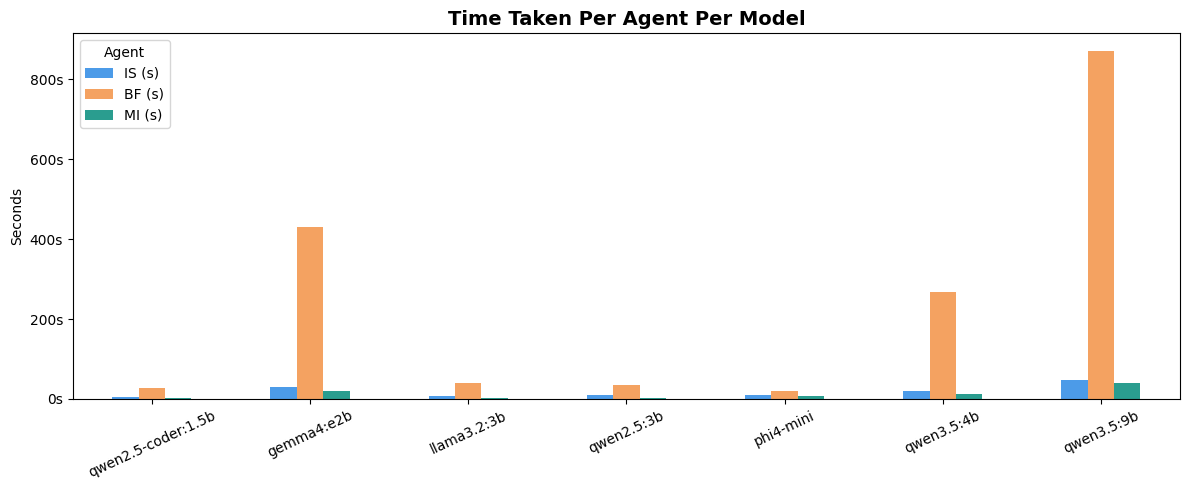


Timing Table:


,IS (s),BF (s),MI (s),Total (s)
Model,,,,
qwen2.5-coder:1.5b,4.0,27.3,2.4,33.7
gemma4:e2b,29.8,429.1,18.7,477.6
llama3.2:3b,7.8,39.8,3.5,51.1
qwen2.5:3b,9.7,34.3,3.2,47.2
phi4-mini,9.8,19.3,7.1,36.2
qwen3.5:4b,19.4,267.8,12.4,299.6
qwen3.5:9b,47.4,871.2,38.9,957.5


In [10]:
timing_rows = []
for r in data:
    timing_rows.append({
        'Model': r['model'],
        'IS (s)': r.get('is', {}).get('elapsed_sec', 0),
        'BF (s)': r.get('bf', {}).get('elapsed_sec', 0),
        'MI (s)': r.get('mi', {}).get('elapsed_sec', 0),
        'Total (s)': r.get('total_elapsed_sec', 0),
    })

timing_df = pd.DataFrame(timing_rows).set_index('Model')

fig, ax = plt.subplots(figsize=(12, 5))
timing_df[['IS (s)', 'BF (s)', 'MI (s)']].plot(kind='bar', ax=ax, color=['#4C9BE8', '#F4A261', '#2A9D8F'])
ax.set_title('Time Taken Per Agent Per Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Seconds')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Agent')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%ds'))
plt.tight_layout()
plt.show()

print('\nTiming Table:')
display(timing_df)

## 2 — Input Structuring Agent (IS) Score Breakdown

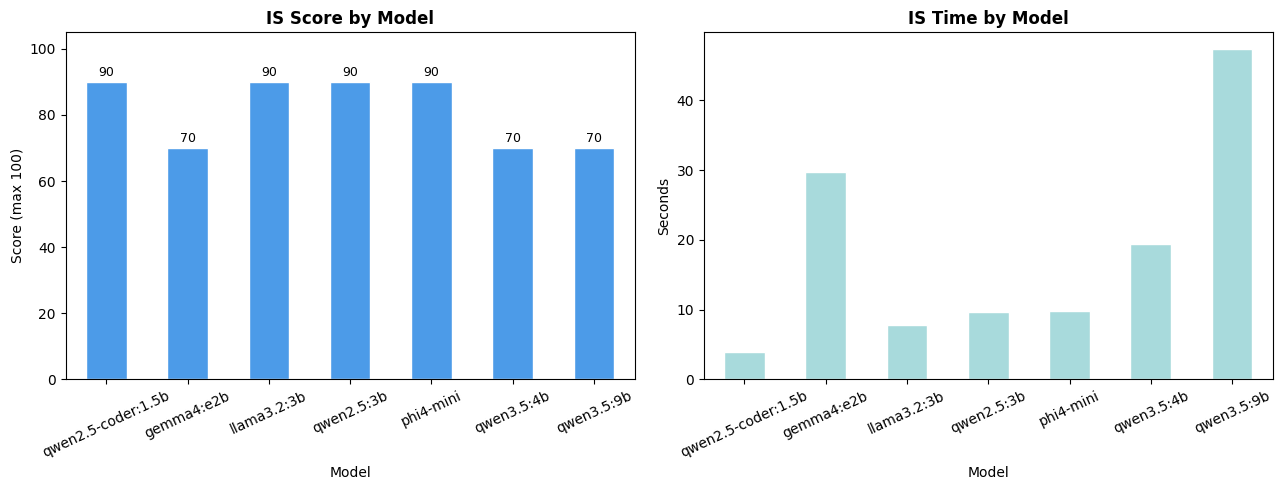


IS Detail Table:


,IS Score,Key Coverage %,Has Summary,Has Unknowns,Has Inferred,Time (s)
Model,,,,,,
qwen2.5-coder:1.5b,90.0,80,Yes,Yes,Yes,4.0
gemma4:e2b,70.0,80,Yes,No,No,29.8
llama3.2:3b,90.0,80,Yes,Yes,Yes,7.8
qwen2.5:3b,90.0,80,Yes,Yes,Yes,9.7
phi4-mini,90.0,80,Yes,Yes,Yes,9.8
qwen3.5:4b,70.0,80,Yes,No,No,19.4
qwen3.5:9b,70.0,80,Yes,No,No,47.4


In [11]:
is_rows = []
for r in data:
    s = r.get('is', {}).get('scores', {})
    is_rows.append({
        'Model': r['model'],
        'IS Score': s.get('score', 0),
        'Key Coverage %': s.get('key_coverage', 0),
        'Has Summary': 'Yes' if s.get('has_summary') else 'No',
        'Has Unknowns': 'Yes' if s.get('has_unknowns') else 'No',
        'Has Inferred': 'Yes' if s.get('has_inferred') else 'No',
        'Time (s)': r.get('is', {}).get('elapsed_sec', 0),
    })

is_df = pd.DataFrame(is_rows).set_index('Model')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Score bar
is_df['IS Score'].plot(kind='bar', ax=axes[0], color='#4C9BE8', edgecolor='white')
axes[0].set_title('IS Score by Model', fontweight='bold')
axes[0].set_ylabel('Score (max 100)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=25)
for bar in axes[0].patches:
    axes[0].annotate(f"{bar.get_height():.0f}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height() + 1),
                     ha='center', va='bottom', fontsize=9)

# Time bar
is_df['Time (s)'].plot(kind='bar', ax=axes[1], color='#A8DADC', edgecolor='white')
axes[1].set_title('IS Time by Model', fontweight='bold')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print('\nIS Detail Table:')
display(is_df)

## 3 — Base Filtering Agent (BF): Decision Breakdown per Model

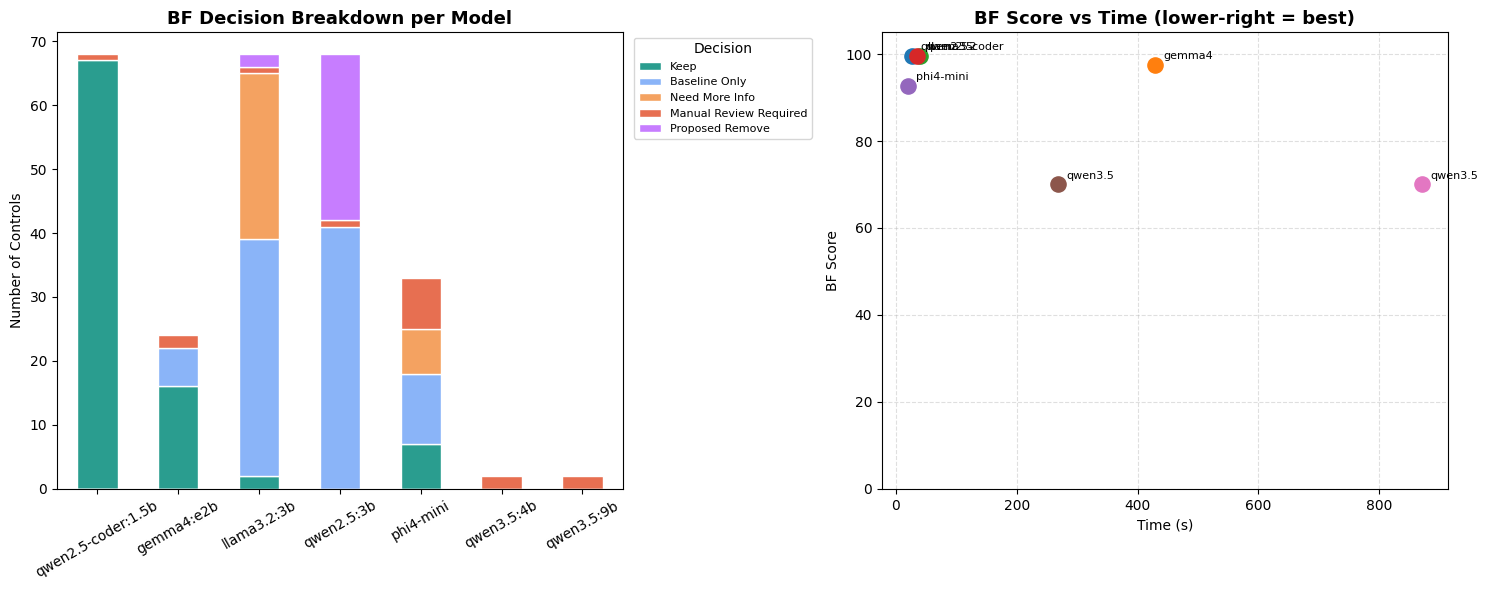


Base Filtering Summary Table:


,Total Controls,Valid Decisions,Validity %,BF Score,Time (s),Keep,Baseline Only,Need More Info,Manual Review Required,Proposed Remove
Model,,,,,,,,,,
qwen2.5-coder:1.5b,68,68,100.0,99.6,27.3,67,0,0,1,0
gemma4:e2b,24,24,100.0,97.5,429.1,16,6,0,2,0
llama3.2:3b,68,68,100.0,99.6,39.8,2,37,26,1,2
qwen2.5:3b,68,68,100.0,99.6,34.3,0,41,0,1,26
phi4-mini,33,33,100.0,92.7,19.3,7,11,7,8,0
qwen3.5:4b,2,2,100.0,70.0,267.8,0,0,0,2,0
qwen3.5:9b,2,2,100.0,70.0,871.2,0,0,0,2,0


In [12]:
DECISION_TYPES = ['Keep', 'Baseline Only', 'Need More Info', 'Manual Review Required', 'Proposed Remove']
COLORS = ['#2A9D8F', '#8AB4F8', '#F4A261', '#E76F51', '#C77DFF']

bf_rows = []
for r in data:
    bf = r.get('bf', {})
    spread = bf.get('scores', {}).get('decision_spread', {})
    scores = bf.get('scores', {})
    row = {
        'Model': r['model'],
        'Total Controls': scores.get('total_controls', 0),
        'Valid Decisions': scores.get('valid_decisions', 0),
        'Validity %': scores.get('validity_pct', 0),
        'BF Score': scores.get('score', 0),
        'Time (s)': bf.get('elapsed_sec', 0),
    }
    for d in DECISION_TYPES:
        row[d] = spread.get(d, 0)
    bf_rows.append(row)

bf_df = pd.DataFrame(bf_rows).set_index('Model')

# Stacked bar: decision breakdown
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

decision_counts = bf_df[DECISION_TYPES]
decision_counts.plot(kind='bar', stacked=True, ax=axes[0], color=COLORS, edgecolor='white')
axes[0].set_title('BF Decision Breakdown per Model', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Controls')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Decision', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Score vs time scatter
ax2 = axes[1]
for i, (model, row) in enumerate(bf_df.iterrows()):
    ax2.scatter(row['Time (s)'], row['BF Score'], s=120, label=model, zorder=3)
    ax2.annotate(model.split(':')[0], (row['Time (s)'], row['BF Score']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
ax2.set_title('BF Score vs Time (lower-right = best)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('BF Score')
ax2.set_ylim(0, 105)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print('\nBase Filtering Summary Table:')
display(bf_df)

## 4 — Per-Model BF Decision Detail (counts + %)

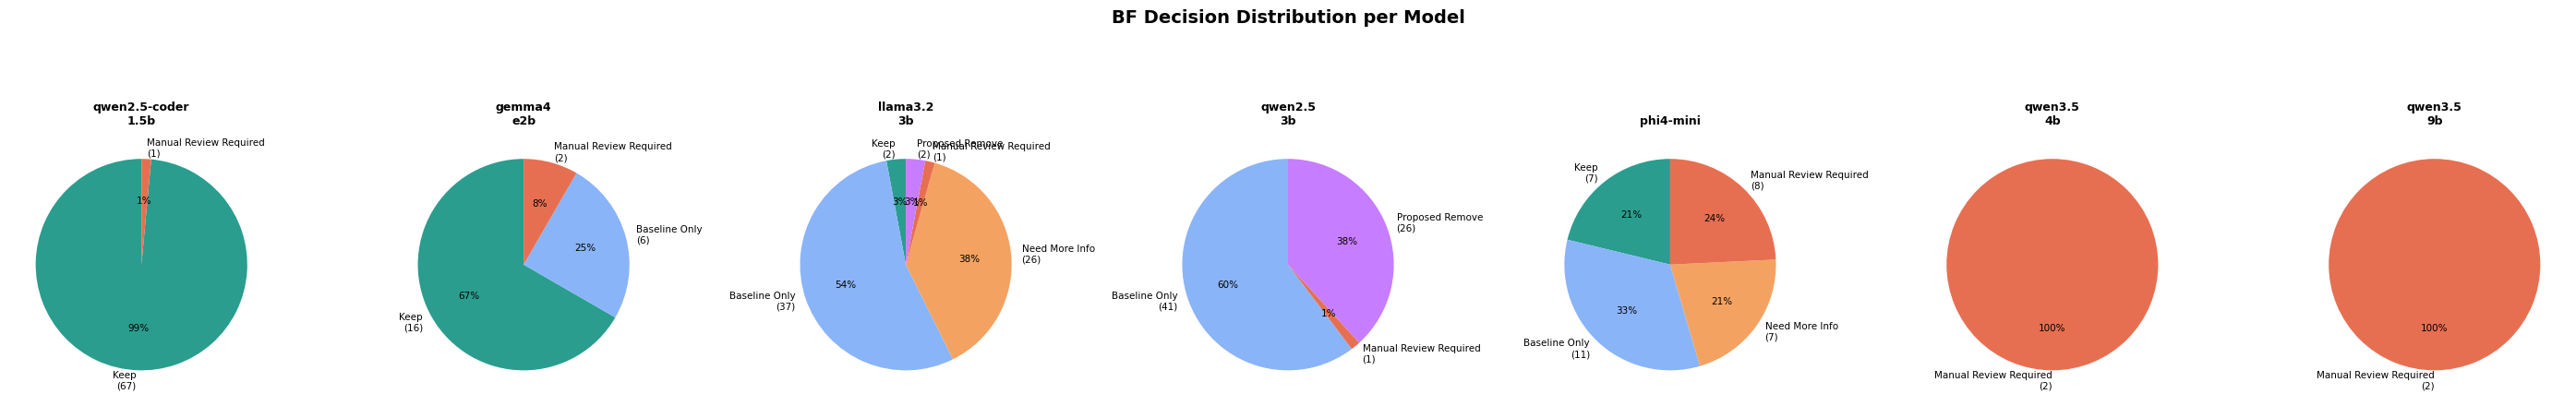

In [13]:
fig, axes = plt.subplots(1, len(data), figsize=(4 * len(data), 5), sharey=False)
if len(data) == 1:
    axes = [axes]

for ax, r in zip(axes, data):
    model = r['model']
    spread = r.get('bf', {}).get('scores', {}).get('decision_spread', {})
    counts = [spread.get(d, 0) for d in DECISION_TYPES]
    total = sum(counts)
    labels = [f"{d}\n({c})" for d, c in zip(DECISION_TYPES, counts) if c > 0]
    sizes = [c for c in counts if c > 0]
    colors_used = [COLORS[i] for i, c in enumerate(counts) if c > 0]

    if sizes:
        wedges, texts, autotexts = ax.pie(
            sizes, labels=labels, colors=colors_used,
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 7.5}
        )
    ax.set_title(model.replace(':', '\n'), fontsize=9, fontweight='bold')

plt.suptitle('BF Decision Distribution per Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5 — Missing Info Agent (MI) Score Breakdown

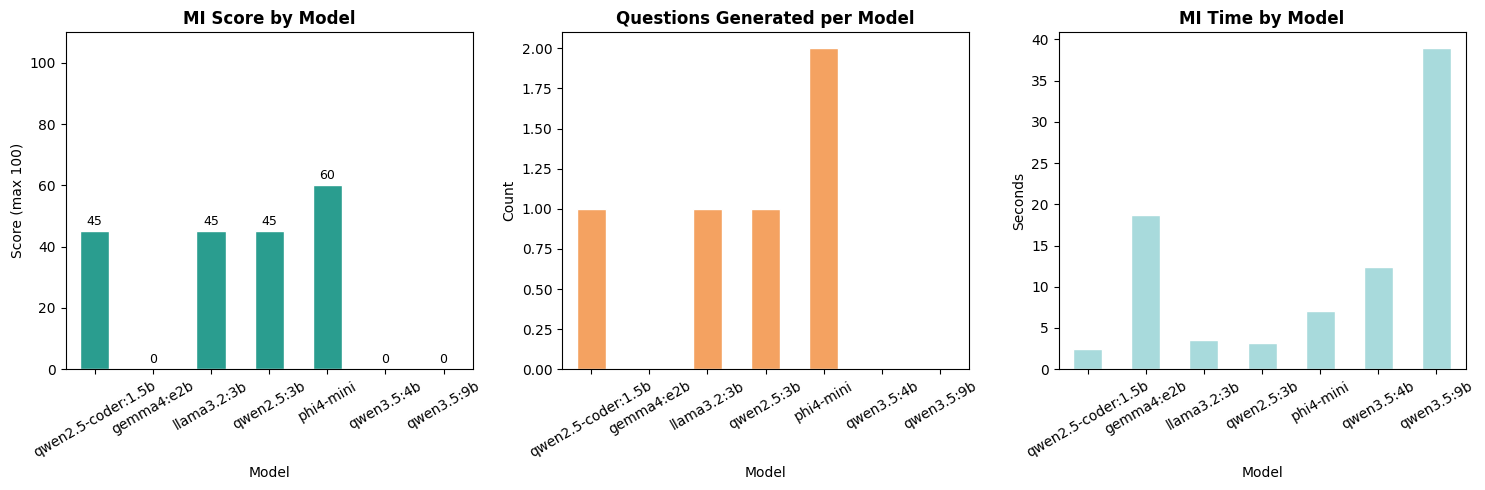


MI Detail Table:


,MI Score,Questions Generated,Critical Gaps,Question Quality %,Time (s)
Model,,,,,
qwen2.5-coder:1.5b,45.0,1,1,100,2.4
gemma4:e2b,0.0,0,0,0,18.7
llama3.2:3b,45.0,1,1,100,3.5
qwen2.5:3b,45.0,1,1,100,3.2
phi4-mini,60.0,2,2,100,7.1
qwen3.5:4b,0.0,0,0,0,12.4
qwen3.5:9b,0.0,0,0,0,38.9


In [14]:
mi_rows = []
for r in data:
    mi = r.get('mi', {})
    s = mi.get('scores', {})
    mi_rows.append({
        'Model': r['model'],
        'MI Score': s.get('score', 0),
        'Questions Generated': s.get('questions_generated', 0),
        'Critical Gaps': s.get('critical_gaps', 0),
        'Question Quality %': s.get('question_quality_pct', 0),
        'Time (s)': mi.get('elapsed_sec', 0),
    })

mi_df = pd.DataFrame(mi_rows).set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

mi_df['MI Score'].plot(kind='bar', ax=axes[0], color='#2A9D8F', edgecolor='white')
axes[0].set_title('MI Score by Model', fontweight='bold')
axes[0].set_ylabel('Score (max 100)')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].annotate(f"{bar.get_height():.0f}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height() + 1),
                     ha='center', va='bottom', fontsize=9)

mi_df['Questions Generated'].plot(kind='bar', ax=axes[1], color='#F4A261', edgecolor='white')
axes[1].set_title('Questions Generated per Model', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

mi_df['Time (s)'].plot(kind='bar', ax=axes[2], color='#A8DADC', edgecolor='white')
axes[2].set_title('MI Time by Model', fontweight='bold')
axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('\nMI Detail Table:')
display(mi_df)